<a href="https://colab.research.google.com/github/DymaStar/DTA_2026/blob/main/HW/DS_HW160626%22practice_stat_tests_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Статистичні тести: практикум

**Тривалість:** ~4 години · бібліотека `scipy.stats`

---

Цей практикум закріплює лекцію про p-значення та статистичну значущість. Він влаштований так:

- 🟦 **Теорія** — короткий блок перед кожним тестом: *коли* його обирати, *чому*, *як читати результат*.
- ✏️ **Завдання (код)** — ви пишете код, що проводить тест.
- 💬 **Інтерпретація** — ви **своїми словами** пояснюєте, що означає результат. Це найважливіша частина! Аналітик, який уміє порахувати p-значення, але не вміє його пояснити — це лише калькулятор.

## Як працювати
1. Читайте теоретичний блок.
2. Виконуйте завдання на код (Shift+Enter).
3. На кожне питання інтерпретації відповідайте **повним реченням людською мовою** — так, ніби пояснюєте керівнику без технічної освіти.

## Загальне правило
- `p < 0.05` → статистично значущо → відхиляємо H₀
- `p ≥ 0.05` → не значущо → не відхиляємо H₀

> 💡 Тримайте поруч шпаргалку вибору тесту з лекції. Половина завдань — про те, щоб **обрати правильний тест**.

---

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Підготовка

Запустіть цю клітинку. Ми працюємо з двома наборами даних:
- **`shop_customers.csv`** — 500 клієнтів інтернет-магазину
- **`ab_test.csv`** — результати A/B-тесту (8000 сесій)


In [24]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/DataBase/data/shop_customers.csv")
ab = pd.read_csv("/content/drive/MyDrive/DataBase/data/ab_test.csv")

print("Клієнти:", df.shape)
print("A/B тест:", ab.shape)
df.head()

Клієнти: (500, 11)
A/B тест: (8000, 3)


,customer_id,gender,age,country,channel,device,spend,session_min,sat_before,sat_after,purchased
0,1001,Ч,23,Німеччина,Реклама,Desktop,997.11,22.2,6,7,Так
1,1002,Ч,38,Україна,Органіка,Desktop,510.09,19.8,5,8,Ні
2,1003,Ч,20,Україна,Соцмережі,Desktop,789.71,21.0,7,8,Ні
3,1004,Ч,40,Німеччина,Соцмережі,Desktop,1041.02,17.4,8,9,Ні
4,1005,Ч,18,Україна,Реклама,Desktop,944.34,23.5,6,7,Ні


### Опис даних `shop_customers.csv`

| Стовпець | Опис | Тип |
|---|---|---|
| `customer_id` | ID клієнта | — |
| `gender` | Стать (Ч/Ж) | категоріальний |
| `age` | Вік | числовий |
| `country` | Країна | категоріальний |
| `channel` | Канал залучення (Органіка/Реклама/Соцмережі) | категоріальний |
| `device` | Пристрій (Mobile/Desktop) | категоріальний |
| `spend` | Витрати клієнта, грн | числовий |
| `session_min` | Час на сайті, хв | числовий |
| `sat_before` | Задоволеність ДО редизайну (1-10) | числовий |
| `sat_after` | Задоволеність ПІСЛЯ редизайну (1-10) | числовий |
| `purchased` | Чи зробив покупку (Так/Ні) | категоріальний |

Спочатку завжди корисно роздивитись дані.

#### ✏️ Завдання 1 (код)

Виведіть основну статистику по числових стовпцях (підказка: метод `.describe()`).

In [25]:
# Завдання 1:
df.describe()

,customer_id,age,spend,session_min,sat_before,sat_after
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,1250.500000,34.646000,845.016340,20.739400,6.536000,7.138000
std,144.481833,10.961615,333.460589,10.532489,1.523597,1.826919
min,1001.000000,18.000000,50.000000,1.000000,2.000000,1.000000
25%,1125.750000,26.000000,612.627500,13.100000,6.000000,6.000000
50%,1250.500000,34.000000,834.750000,20.850000,7.000000,7.000000
75%,1375.250000,41.250000,1070.395000,27.400000,8.000000,9.000000
max,1500.000000,69.000000,1952.020000,52.200000,10.000000,10.000000


#### ✏️ Завдання 2 (код)

Скільки клієнтів у кожному каналі залучення? (підказка: `.value_counts()` на стовпці `channel`)

In [26]:
# Завдання 2:
df["channel"].value_counts()

,count
channel,
Органіка,174
Соцмережі,167
Реклама,159


---
# Розділ 1. Одновибірковий t-тест

## 🟦 Теорія: коли і чому

**Коли обирати:** коли у вас є **одна** група числових даних, і ви хочете порівняти її **середнє** з якимось **фіксованим, наперед відомим числом** (ціль, норматив, заявлене значення).

**Чому саме він:** ми перевіряємо, чи відхилення нашого середнього від цільового числа реальне, чи це випадковість вибірки.

**Гіпотези:**
- H₀: середнє = цільове число
- H₁: середнє ≠ цільове число

**Функція:** `stats.ttest_1samp(дані, цільове_число)`

**Як читати:** дивимось на p-значення. Якщо `p < 0.05` — середнє значущо відрізняється від цільового.

**Приклад із життя:** виробник заявляє, що пакет чипсів важить 100 г. Ви зважили 50 пакетів. Чи справді середня вага = 100 г, чи вас обманюють?

**Сценарій:** маркетолог стверджує, що середній час на сайті становить 20 хвилин. Перевіримо це.

#### ✏️ Завдання 3 (код)

Порахуйте фактичний середній `session_min`. Потім проведіть одновибірковий t-тест, щоб перевірити, чи відрізняється він від 20. Виведіть t-статистику та p-значення.

In [27]:
# Завдання 3:
# ==========================================
# Завдання 3.
# Одновибірковий t-тест (One Sample t-test)
# Перевіряємо, чи відрізняється середній
# час перебування на сайті від 20 хвилин.
# ==========================================

# Крок 1. Обчислюємо фактичний середній час сесії
mean_session = df["session_min"].mean()

# Виводимо середнє значення
print(f"Фактичний середній час: {mean_session:.2f} хв")


# ==========================================
# Крок 2. Виконуємо одновибірковий t-тест
#
# H0 (нульова гіпотеза):
# середній час = 20 хв
#
# H1 (альтернативна гіпотеза):
# середній час ≠ 20 хв
# ==========================================

t_stat, p_value = stats.ttest_1samp(
    df["session_min"],   # вибірка
    20                   # гіпотетичне середнє
)

# Виводимо t-статистику
print(f"t-статистика: {t_stat:.3f}")

# Виводимо p-value
print(f"p-значення: {p_value:.4f}")


# ==========================================
# Крок 3.
# Робимо статистичний висновок
# при рівні значущості α = 0.05
# ==========================================

if p_value < 0.05:
    print("✅ Середній час статистично значуще відрізняється від 20 хв")
else:
    print("❌ Статистично значущої різниці від 20 хв НЕ виявлено")

Фактичний середній час: 20.74 хв
t-статистика: 1.570
p-значення: 0.1171
❌ Статистично значущої різниці від 20 хв НЕ виявлено


#### 💬 Інтерпретація 1

Чи відрізняється середній час на сайті від заявлених 20 хвилин? Сформулюйте висновок для маркетолога: він мав рацію чи ні? Чому ви так вважаєте (спирайтесь на p-значення)?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Середній час на сайті ≈ **20.74 хв**, а p-значення ≈ **0.1171**. Оскільки `p ≥ 0.05`, ми **не відхиляємо H₀**. Це означає, що статистично значущої різниці від 20 хвилин не виявлено. Для маркетолога висновок такий: твердження про 20 хвилин не суперечить цим даним.

**Другий сценарій:** керівник вважає, що середні витрати клієнта = 850 грн.

#### ✏️ Завдання 4 (код)

Перевірте за допомогою одновибіркового t-тесту, чи середні витрати (`spend`) відрізняються від 850 грн.

In [28]:
# Завдання 4:
# ==========================================
# Завдання 4.
# Одновибірковий t-тест (One Sample t-test)
# Перевіряємо, чи відрізняються середні
# витрати клієнта від 850 грн.
# ==========================================

# Крок 1. Обчислюємо фактичні середні витрати
mean_spend = df["spend"].mean()

# Виводимо середнє значення
print(f"Середні витрати: {mean_spend:.1f} грн")


# ==========================================
# Крок 2.
# Виконуємо одновибірковий t-тест.
#
# H0 (нульова гіпотеза):
# середні витрати = 850 грн
#
# H1 (альтернативна гіпотеза):
# середні витрати ≠ 850 грн
# ==========================================

t_stat, p_value = stats.ttest_1samp(
    df["spend"],   # вибірка
    850            # гіпотетичне середнє
)

# Виводимо t-статистику
print(f"t-статистика: {t_stat:.3f}")

# Виводимо p-value
print(f"p-значення: {p_value:.4f}")


# ==========================================
# Крок 3.
# Робимо статистичний висновок
# при рівні значущості α = 0.05
# ==========================================

if p_value < 0.05:
    print("✅ Середні витрати статистично значуще відрізняються від 850 грн")
else:
    print("❌ Статистично значущої різниці від 850 грн НЕ виявлено")

Середні витрати: 845.0 грн
t-статистика: -0.334
p-значення: 0.7384
❌ Статистично значущої різниці від 850 грн НЕ виявлено


#### 💬 Інтерпретація 2

Що показав тест? Чи можна сказати, що середні витрати дорівнюють 850 грн? Поясніть, чому тут ми НЕ відхиляємо нульову гіпотезу (зверніть увагу на формулювання: чи це означає, що середнє точно дорівнює 850?).

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Середні витрати ≈ **845 грн**, p-значення ≈ **0.7384**. Оскільки `p ≥ 0.05`, ми **не відхиляємо H₀**. Але це не означає, що середнє точно дорівнює 850 грн. Це означає лише, що за цими даними немає достатніх доказів, що середні витрати статистично значущо відрізняються від 850 грн.

---
# Розділ 2. Двовибірковий t-тест (незалежні групи)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви порівнюєте **середні двох РІЗНИХ, незалежних груп** числових даних.

**Чому саме він:** хочемо дізнатись, чи різниця між групами реальна, чи могла виникнути випадково.

**Ключова умова — групи НЕЗАЛЕЖНІ:** різні люди в кожній групі (на відміну від парного тесту, де ті самі люди двічі).

**Гіпотези:**
- H₀: середнє групи 1 = середнє групи 2
- H₁: вони відрізняються

**Функція:** `stats.ttest_ind(група1, група2)`

**Приклад із життя:** чи відрізняється середня зарплата у двох відділах? Чи витрачають більше клієнти з міста А порівняно з містом Б?

**Сценарій:** чи витрачають клієнти з мобільних більше, ніж з десктопу?

#### ✏️ Завдання 5 (код)

Розділіть `spend` на дві групи за `device` (Mobile та Desktop). Виведіть середнє кожної групи і проведіть двовибірковий t-тест.

In [29]:
# Завдання 5:
# ===========================================
# Завдання 5
# Двовибірковий t-тест (Mobile vs Desktop)
# ===========================================

# Виділяємо витрати користувачів з мобільних пристроїв
spend_mobile = df[df["device"] == "Mobile"]["spend"]

# Виділяємо витрати користувачів з комп'ютерів
spend_desktop = df[df["device"] == "Desktop"]["spend"]

# Виводимо середні витрати кожної групи
print(f"Mobile:  {spend_mobile.mean():.1f} грн")
print(f"Desktop: {spend_desktop.mean():.1f} грн")

# Виконуємо двовибірковий t-тест
# H0: середні витрати однакові
# H1: середні витрати відрізняються
t_stat, p_value = stats.ttest_ind(spend_mobile, spend_desktop)

# Виводимо результати тесту
print(f"t-статистика: {t_stat:.3f}")
print(f"p-значення:   {p_value:.4f}")

# Робимо статистичний висновок
if p_value < 0.05:
    print("✅ Значуща різниця між пристроями")
else:
    print("❌ Значущої різниці НЕ виявлено")

Mobile:  835.2 грн
Desktop: 861.2 грн
t-статистика: -0.844
p-значення:   0.3993
❌ Значущої різниці НЕ виявлено


#### 💬 Інтерпретація 3

Чи є значуща різниця у витратах між Mobile та Desktop? Якби ви були аналітиком, чи порадили б компанії інвестувати в мобільну версію на основі цього результату?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Mobile має середні витрати ≈ **835.2 грн**, Desktop ≈ **861.2 грн**, p-значення ≈ **0.3993**. Оскільки `p ≥ 0.05`, значущої різниці у витратах між Mobile та Desktop не виявлено. Тому лише на основі цього тесту я б не радив робити великий інвестиційний висновок на користь мобільної версії — потрібні інші метрики: конверсія, retention, UX, частка трафіку.


**Сценарій:** чи різниться час на сайті залежно від статі?

#### ✏️ Завдання 6 (код)

Порівняйте `session_min` між чоловіками та жінками за допомогою двовибіркового t-тесту.

In [30]:
# Завдання 6:
# ===========================================
# Двовибірковий t-тест: session_min за статтю
# ===========================================

# Розділяємо час на сайті на дві незалежні групи: чоловіки та жінки
session_m = df[df["gender"] == "Ч"]["session_min"]
session_f = df[df["gender"] == "Ж"]["session_min"]

# Дивимось середні значення в кожній групі
print(f"Чоловіки: {session_m.mean():.2f} хв")
print(f"Жінки:    {session_f.mean():.2f} хв")

# H0: середній час на сайті однаковий для чоловіків і жінок
# H1: середній час на сайті відрізняється
# equal_var=False — безпечніший варіант тесту Велча, якщо дисперсії груп різні
t_stat, p_value = stats.ttest_ind(session_m, session_f, equal_var=False)

print(f"t-статистика: {t_stat:.3f}")
print(f"p-значення:   {p_value:.4f}")

if p_value < 0.05:
    print("✅ Є статистично значуща різниця в часі на сайті між чоловіками та жінками")
else:
    print("❌ Значущої різниці в часі на сайті між чоловіками та жінками НЕ виявлено")


Чоловіки: 20.85 хв
Жінки:    20.63 хв
t-статистика: 0.232
p-значення:   0.8164
❌ Значущої різниці в часі на сайті між чоловіками та жінками НЕ виявлено


#### 💬 Інтерпретація 4

Сформулюйте висновок. Якщо різниця не значуща — що це означає на практиці для команди маркетингу?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

У чоловіків середній час на сайті ≈ **20.85 хв**, у жінок ≈ **20.63 хв**. p-значення ≈ **0.8164**, тобто `p ≥ 0.05`. Отже, статистично значущої різниці між чоловіками та жінками за часом на сайті **не виявлено**. Для маркетингу це означає, що не варто будувати окрему стратегію лише на припущенні, що одна стать проводить на сайті більше часу.


---
# Розділ 3. Парний t-тест

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви маєте **два виміри в ОДНИХ І ТИХ САМИХ обʼєктів** — типово «до і після» якоїсь зміни.

**Чому саме він (а не звичайний t-тест):** виміри пов'язані (той самий клієнт до і після). Парний тест враховує цей зв'язок і тому **потужніший** — він краще виявляє реальні зміни.

**Гіпотези:**
- H₀: середня різниця (після − до) = 0 (зміни немає)
- H₁: середня різниця ≠ 0 (зміна є)

**Функція:** `stats.ttest_rel(до, після)`

**Приклад із життя:** вага пацієнтів до і після дієти. Продуктивність працівників до і після тренінгу. Бали студентів до і після курсу.

> ⚠️ Головна підказка для вибору: якщо ви бачите слова «до/після», «був/став», «той самий обʼєкт двічі» — це парний тест.

**Сценарій:** компанія зробила редизайн сайту і виміряла задоволеність тих самих клієнтів до (`sat_before`) і після (`sat_after`).

#### ✏️ Завдання 7 (код)

Проведіть парний t-тест, щоб перевірити, чи змінилася задоволеність клієнтів після редизайну. Виведіть середні значення до і після, а також p-значення.

In [31]:
# Завдання 7:
# ==========================================
# Завдання 7.
# Парний t-тест: задоволеність до і після редизайну
# ==========================================

# Виводимо середню задоволеність до редизайну
print(f"Задоволеність ДО: {df['sat_before'].mean():.2f}")

# Виводимо середню задоволеність після редизайну
print(f"Задоволеність ПІСЛЯ: {df['sat_after'].mean():.2f}")

# Виконуємо парний t-тест.
# H0: середня різниця між sat_after і sat_before дорівнює 0
# H1: середня різниця не дорівнює 0
t_stat, p_value = stats.ttest_rel(
    df["sat_before"],   # значення до редизайну
    df["sat_after"]     # значення після редизайну
)

# Виводимо p-value у науковому форматі
print(f"\np-значення: {p_value:.2e}")

# Робимо висновок за рівнем значущості 0.05
if p_value < 0.05:
    print("✅ Задоволеність значущо змінилася")
else:
    print("❌ Значущої зміни НЕ виявлено")

Задоволеність ДО: 6.54
Задоволеність ПІСЛЯ: 7.14

p-значення: 1.57e-26
✅ Задоволеність значущо змінилася


#### 💬 Інтерпретація 5

Чи спрацював редизайн? Поясніть, чому тут доречний саме ПАРНИЙ тест, а не звичайний двовибірковий. Що було б не так, якби ми використали `ttest_ind`?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Після редизайну середня задоволеність зросла з ≈ **6.54** до ≈ **7.14**, p-значення дуже мале (`p < 0.05`). Отже, зміна статистично значуща, і можна сказати, що редизайн спрацював. Тут потрібен саме **парний t-тест**, бо порівнюються ті самі клієнти «до» і «після». Звичайний `ttest_ind` був би менш правильним, бо він вважає групи незалежними.


---
# Розділ 4. ANOVA (дисперсійний аналіз)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви порівнюєте середні **ТРЬОХ або більше груп** числових даних.

**Чому не кілька t-тестів:** якби ми порівнювали групи попарно багатьма t-тестами, ми б накопичили помилки I роду (згадайте проблему множинних порівнянь!). ANOVA перевіряє все одним тестом.

**Гіпотези:**
- H₀: середні ВСІХ груп однакові
- H₁: принаймні одна група відрізняється

**Функція:** `stats.f_oneway(група1, група2, група3, ...)`

**Важливе обмеження:** ANOVA каже, що різниця Є, але не каже, **між якими саме** групами. Для цього потрібні додаткові (post-hoc) тести.

**Приклад із життя:** чи відрізняється врожайність при трьох різних добривах? Чи різний середній дохід у чотирьох регіонах?

**Сценарій:** чи залежать витрати клієнта від каналу залучення (Органіка / Реклама / Соцмережі)?

#### ✏️ Завдання 8 (код)

Виведіть середні `spend` для кожного каналу. Потім проведіть ANOVA, щоб перевірити, чи є значуща різниця між каналами. (Підказка: створіть список груп через цикл або вручну, потім передайте їх у `f_oneway`.)

In [32]:
# Завдання 8:
# ===========================================
# Завдання 8
# ANOVA — порівняння середніх витрат між каналами
# ===========================================

# Виводимо середні витрати для кожного каналу
for ch in df["channel"].unique():
    print(f"{ch}: {df[df['channel'] == ch]['spend'].mean():.1f} грн")

# Формуємо список вибірок.
# Кожен елемент списку містить значення spend лише одного каналу.
groups = [
    df[df["channel"] == ch]["spend"]
    for ch in df["channel"].unique()
]

# ---------------------------------------------------------
# Варіант 1 (рекомендований)
# Передаємо список груп через оператор *
# Працює з будь-якою кількістю каналів.
# ---------------------------------------------------------

f_stat, p_value = stats.f_oneway(*groups)

# ---------------------------------------------------------
# Варіант 2
# Якщо точно відомо, що каналів лише три.
# (закоментований)
# ---------------------------------------------------------

# f_stat, p_value = stats.f_oneway(groups[0], groups[1], groups[2])

print(f"\nF-статистика: {f_stat:.2f}")
print(f"p-значення: {p_value:.2e}")

if p_value < 0.05:
    print("✅ Принаймні один канал відрізняється")
else:
    print("❌ Значущої різниці НЕ виявлено")

Реклама: 1057.9 грн
Органіка: 791.3 грн
Соцмережі: 698.4 грн

F-статистика: 63.54
p-значення: 2.68e-25
✅ Принаймні один канал відрізняється


#### 💬 Інтерпретація 6

Чи відрізняються канали за витратами? Який канал виглядає найприбутковішим? Чому на основі лише ANOVA ми НЕ можемо точно сказати, що, наприклад, Реклама значущо краща за Органіку?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

ANOVA показала значущу різницю між каналами (`p < 0.05`). За середніми значеннями найприбутковішим виглядає канал **Реклама**: приблизно **1057.9 грн**, тоді як Органіка ≈ **791.3 грн**, Соцмережі ≈ **698.4 грн**. Але ANOVA показує лише, що принаймні один канал відрізняється. Щоб точно сказати, між якими саме каналами різниця значуща, потрібні post-hoc тести.


**Сценарій:** чи залежить час на сайті (`session_min`) від країни клієнта?

#### ✏️ Завдання 9 (код)

Проведіть ANOVA для `session_min` за трьома країнами (`country`).

In [33]:
# Завдання 9:
# ===========================================
# ANOVA: session_min за країнами
# ===========================================

# Виводимо середній час на сайті для кожної країни
country_means = df.groupby("country")["session_min"].mean().sort_values(ascending=False)
print("Середній час на сайті за країнами:")
print(country_means.round(2))

# Формуємо групи для ANOVA
country_groups = [
    group["session_min"]
    for _, group in df.groupby("country")
]

# H0: середній час на сайті однаковий у всіх країнах
# H1: принаймні одна країна відрізняється
f_stat, p_value = stats.f_oneway(*country_groups)

print(f"\nF-статистика: {f_stat:.3f}")
print(f"p-значення:   {p_value:.4f}")

if p_value < 0.05:
    print("✅ Середній час на сайті статистично значуще відрізняється між країнами")
else:
    print("❌ Значущої різниці між країнами за часом на сайті НЕ виявлено")


Середній час на сайті за країнами:
country
Німеччина    21.29
Польща       21.17
Україна      20.29
Name: session_min, dtype: float64

F-статистика: 0.493
p-значення:   0.6111
❌ Значущої різниці між країнами за часом на сайті НЕ виявлено


#### 💬 Інтерпретація 7

Що показав результат? Сформулюйте висновок про звʼязок країни і часу на сайті.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Середній час на сайті: Німеччина ≈ **21.29 хв**, Польща ≈ **21.17 хв**, Україна ≈ **20.29 хв**. ANOVA дала p-значення ≈ **0.6111**, тобто `p ≥ 0.05`. Статистично значущої різниці між країнами за середнім часом на сайті **не виявлено**. Тому за цими даними не можна стверджувати, що країна суттєво впливає на тривалість сесії.


---
# Розділ 5. Хі-квадрат (χ²)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли обидві змінні **категоріальні**, і ви хочете перевірити, чи є між ними **звʼязок**.

**Чому саме він:** t-тест і ANOVA працюють із числами (середніми). Коли даних немає що усереднювати (категорії на кшталт «купив/не купив», «місто», «колір»), використовують хі-квадрат на основі **частот**.

**Гіпотези:**
- H₀: змінні незалежні (звʼязку немає)
- H₁: змінні повʼязані

**Як проводити (два кроки):**
1. Побудувати таблицю спряженості: `pd.crosstab(змінна1, змінна2)`
2. Передати її у `stats.chi2_contingency(таблиця)` — повертає chi2, p, dof, expected

**Приклад із життя:** чи повʼязана стать із вибором категорії товару? Чи залежить рішення про покупку від кольору кнопки (це і є A/B-тест для конверсій!)?

**Сценарій:** чи повʼязаний канал залучення (`channel`) із фактом покупки (`purchased`)?

#### ✏️ Завдання 10 (код)

Побудуйте таблицю спряженості між `channel` та `purchased`, виведіть її, потім проведіть тест хі-квадрат.

In [34]:
# Завдання 10:
# ===========================================
# Завдання 10
# Перевірка зв'язку між channel та purchased
# за допомогою критерію χ² (хи-квадрат)
# ===========================================

# Крок 1. Будуємо таблицю спряженості
# Рядки - канали залучення
# Стовпці - чи була покупка (Yes/No)
contingency = pd.crosstab(df["channel"], df["purchased"])

print("Таблиця спряженості:")
print(contingency)

# Крок 2. Виконуємо χ²-тест незалежності
# chi2      - значення статистики χ²
# p_value   - p-значення
# dof       - ступені свободи
# expected  - очікувані частоти при H₀
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"\nχ²-статистика: {chi2:.3f}")
print(f"p-значення: {p_value:.4f}")

# Крок 3. Робимо статистичний висновок
if p_value < 0.05:
    print("✅ Канал пов'язаний з покупкою")
else:
    print("❌ Статистично значущого зв'язку НЕ виявлено")

Таблиця спряженості:
purchased   Ні  Так
channel            
Органіка   116   58
Реклама    110   49
Соцмережі  107   60

χ²-статистика: 0.957
p-значення: 0.6198
❌ Статистично значущого зв'язку НЕ виявлено


#### 💬 Інтерпретація 8

Чи виявив тест звʼязок між каналом залучення та покупкою? Сформулюйте висновок. Якщо звʼязку не виявлено — що це означає для бізнесу (чи варто обирати канал, орієнтуючись на ймовірність покупки)? Якщо звʼязок є — подивіться на частки в таблиці спряженості й опишіть, який канал вигідніший.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Для `channel` та `purchased` p-значення ≈ **0.6198**, тобто `p ≥ 0.05`. Статистично значущого зв'язку між каналом залучення та фактом покупки не виявлено. Для бізнесу це означає: за цими даними не варто обирати канал лише за ймовірністю покупки; краще також дивитися на вартість залучення, середній чек і прибуток.


**Сценарій:** чи повʼязана стать (`gender`) із вибором пристрою (`device`)?

#### ✏️ Завдання 11 (код)

Перевірте за допомогою хі-квадрат, чи є звʼязок між статтю та пристроєм.

In [35]:
# Завдання 11:
# ===========================================
# Хі-квадрат: gender × device
# ===========================================

# Таблиця спряженості: стать проти пристрою
contingency = pd.crosstab(df["gender"], df["device"])
print("Таблиця спряженості:")
print(contingency)

# Додатково дивимось частки всередині кожної статі
print("\nЧастки пристроїв усередині кожної статі:")
print(pd.crosstab(df["gender"], df["device"], normalize="index").round(3))

# H0: стать і пристрій незалежні
# H1: між статтю і пристроєм є зв'язок
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"\nχ²-статистика: {chi2:.3f}")
print(f"p-значення:    {p_value:.4f}")

if p_value < 0.05:
    print("✅ Є статистично значущий зв'язок між статтю та пристроєм")
else:
    print("❌ Статистично значущого зв'язку між статтю та пристроєм НЕ виявлено")


Таблиця спряженості:
device  Desktop  Mobile
gender                 
Ж            93     158
Ч            96     153

Частки пристроїв усередині кожної статі:
device  Desktop  Mobile
gender                 
Ж         0.371   0.629
Ч         0.386   0.614

χ²-статистика: 0.065
p-значення:    0.7993
❌ Статистично значущого зв'язку між статтю та пристроєм НЕ виявлено


#### 💬 Інтерпретація 9

Сформулюйте висновок. Чи можна за цими даними сказати, що чоловіки й жінки користуються різними пристроями?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Для зв'язку між статтю та пристроєм p-значення ≈ **0.7993**, тобто `p ≥ 0.05`. Статистично значущого зв'язку **не виявлено**. Отже, за цими даними немає доказів, що чоловіки й жінки користуються різними пристроями. Команда не повинна робити окремі висновки про пристрої лише на основі статі.


---
# Розділ 6. Кореляція

## 🟦 Теорія: коли і чому

**Коли обирати:** коли обидві змінні **числові**, і ви хочете виміряти **силу та напрямок звʼязку** між ними.

**Що повертає:** коефіцієнт кореляції **r** (від −1 до +1) ТА p-значення.
- **r ≈ +1** — сильний прямий звʼязок (одне зростає → інше зростає)
- **r ≈ −1** — сильний зворотний звʼязок (одне зростає → інше спадає)
- **r ≈ 0** — звʼязку немає
- **p-значення** — чи є цей звʼязок статистично значущим

**Функція:** `stats.pearsonr(змінна1, змінна2)`

**Гіпотези:**
- H₀: кореляції немає (r = 0)
- H₁: кореляція є (r ≠ 0)

> ⚠️ **Найважливіше попередження:** кореляція ≠ причинність! Значуща кореляція каже, що звʼязок реальний, але НЕ каже, що одне СПРИЧИНЯЄ інше.

**Приклад із життя:** чи повʼязаний зріст із вагою? Чи більше реклами → більше продажів?

**Сценарій:** чи повʼязаний час на сайті (`session_min`) із витратами (`spend`)?

#### ✏️ Завдання 12 (код)

Порахуйте кореляцію Пірсона між `session_min` та `spend`. Виведіть коефіцієнт r та p-значення. Додатково: побудуйте діаграму розсіювання (scatter plot), щоб побачити звʼязок очима.

Коефіцієнт кореляції r: 0.732
p-значення: 4.05e-85


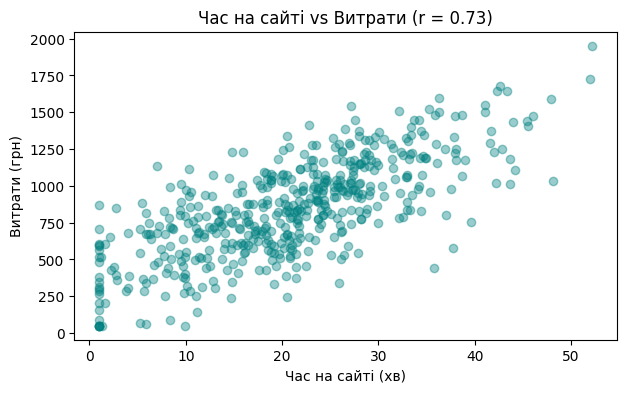

✅ Кореляція статистично значуща


In [36]:
# ===========================================
# Завдання 12
# Кореляція Пірсона між session_min та spend
# ===========================================

# Крок 1. Обчислюємо коефіцієнт кореляції Пірсона
# r - сила та напрямок зв'язку
# p_value - перевірка статистичної значущості
r, p_value = stats.pearsonr(df["session_min"], df["spend"])

print(f"Коефіцієнт кореляції r: {r:.3f}")
print(f"p-значення: {p_value:.2e}")

# Крок 2. Будуємо діаграму розсіювання
# щоб візуально оцінити зв'язок між змінними
plt.figure(figsize=(7, 4))

plt.scatter(
    df["session_min"],
    df["spend"],
    alpha=0.4,
    color="teal"
)

plt.xlabel("Час на сайті (хв)")
plt.ylabel("Витрати (грн)")
plt.title(f"Час на сайті vs Витрати (r = {r:.2f})")

plt.show()

# Крок 3. Робимо статистичний висновок
if p_value < 0.05:
    print("✅ Кореляція статистично значуща")
else:
    print("❌ Статистично значущої кореляції НЕ виявлено")

#### 💬 Інтерпретація 10

Опишіть звʼязок: він прямий чи зворотний? Сильний чи слабкий? Значущий? І найголовніше: чи можна стверджувати, що довший час на сайті СПРИЧИНЯЄ більші витрати? Поясніть свою думку.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Кореляція між часом на сайті та витратами **пряма і досить сильна**: `r ≈ 0.732`, p-значення дуже мале (`p < 0.05`). Це означає, що клієнти, які довше перебувають на сайті, зазвичай витрачають більше. Але кореляція не доводить причинність: ми не можемо автоматично стверджувати, що саме довший час на сайті спричиняє більші витрати.


**Сценарій:** чи повʼязаний вік клієнта (`age`) з його витратами (`spend`)?

#### ✏️ Завдання 13 (код)

Порахуйте кореляцію між `age` та `spend`.

Коефіцієнт кореляції r: -0.042
p-значення: 0.3508


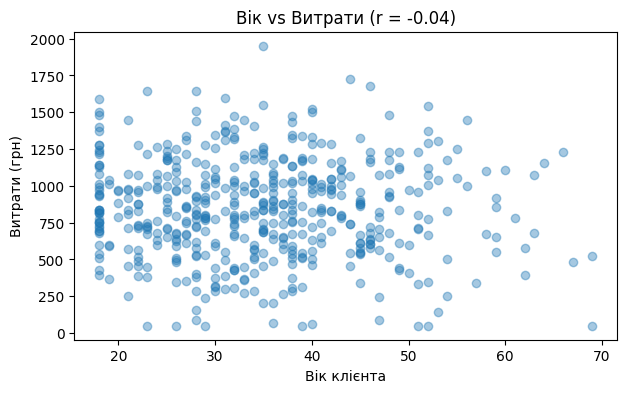

❌ Статистично значущої кореляції НЕ виявлено


In [37]:
# Завдання 13:
# ===========================================
# Кореляція Пірсона між age та spend
# ===========================================

# H0: лінійного зв'язку між віком і витратами немає
# H1: лінійний зв'язок є
r, p_value = stats.pearsonr(df["age"], df["spend"])

print(f"Коефіцієнт кореляції r: {r:.3f}")
print(f"p-значення: {p_value:.4f}")

plt.figure(figsize=(7, 4))
plt.scatter(df["age"], df["spend"], alpha=0.4)
plt.xlabel("Вік клієнта")
plt.ylabel("Витрати (грн)")
plt.title(f"Вік vs Витрати (r = {r:.2f})")
plt.show()

if p_value < 0.05:
    print("✅ Кореляція статистично значуща")
else:
    print("❌ Статистично значущої кореляції НЕ виявлено")


#### 💬 Інтерпретація 11

Що показала кореляція? Порівняйте цей результат із попереднім (час на сайті vs витрати). У якому випадку звʼязок сильніший і чому це важливо для бізнесу?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Кореляція між віком і витратами дуже слабка: `r ≈ -0.042`, p-значення ≈ **0.3508**, тобто `p ≥ 0.05`. Статистично значущого лінійного зв'язку не виявлено. Це набагато слабше, ніж зв'язок між `session_min` та `spend` (`r ≈ 0.732`). Для бізнесу час на сайті виглядає значно кориснішою метрикою для аналізу витрат, ніж вік клієнта.


---
# Розділ 7. 🔥 Велике завдання: A/B-тест

## 🟦 Теорія: A/B-тестування

Це головне застосування статистики в аналітиці. Ми порівнюємо дві версії (A — контроль, B — варіант) і перевіряємо, чи нова версія справді краща, чи різниця випадкова.

Оскільки результат тут — **категоріальний** (конвертувався / ні), ми використовуємо **хі-квадрат** на таблиці спряженості «група × конверсія».

**Дані `ab_test.csv`:**
- `session_id` — ID сесії
- `group` — A (стара версія) або B (нова версія)
- `converted` — 1 (купив) або 0 (не купив)

Це повноцінне завдання, що імітує реальну роботу аналітика. Виконуйте крок за кроком.

**Крок 1. Дослідіть дані.**

#### ✏️ Завдання 14 (код)

Подивіться на дані `ab`: скільки сесій у групі A і скільки в групі B? (підказка: `value_counts` на `group`)

In [38]:
# Завдання 14:
# ===========================================
# A/B-тест: кількість сесій у групах A та B
# ===========================================

# Рахуємо, скільки сесій потрапило в кожну групу
print(ab["group"].value_counts())

# Додатково перевіряємо частки груп
print("\nЧастки груп:")
print(ab["group"].value_counts(normalize=True).round(3))


group
A    4000
B    4000
Name: count, dtype: int64

Частки груп:
group
A    0.5
B    0.5
Name: proportion, dtype: float64


**Крок 2. Порахуйте конверсію кожної групи.**

Конверсія = частка тих, хто купив = середнє значення стовпця `converted` (бо це 0 і 1).

#### ✏️ Завдання 15 (код)

Порахуйте конверсію (середнє `converted`) для групи A і для групи B окремо. (Підказка: `ab.groupby('group')['converted'].mean()`) На скільки відсоткових пунктів відрізняється конверсія?

In [39]:
# Завдання 14:
# ===========================================
# A/B-тест: кількість сесій у групах A та B
# ===========================================

# Рахуємо, скільки сесій потрапило в кожну групу
print(ab["group"].value_counts())

# Додатково перевіряємо частки груп
print("\nЧастки груп:")
print(ab["group"].value_counts(normalize=True).round(3))


group
A    4000
B    4000
Name: count, dtype: int64

Частки груп:
group
A    0.5
B    0.5
Name: proportion, dtype: float64


In [40]:
# Завдання 15:
# ===========================================
# A/B-тест: конверсія в групах A та B
# ===========================================

# Оскільки converted = 1 для покупки і 0 для відсутності покупки,
# середнє значення converted дорівнює конверсії.
conversion = ab.groupby("group")["converted"].mean()

print("Конверсія за групами:")
print((conversion * 100).round(2).astype(str) + "%")

# Різниця у відсоткових пунктах: B - A
if {"A", "B"}.issubset(set(conversion.index)):
    diff_pp = (conversion.loc["B"] - conversion.loc["A"]) * 100
    print(f"\nРізниця B - A: {diff_pp:.2f} відсоткових пунктів")
else:
    print("\nУвага: очікували групи A і B, але в даних інші назви груп.")


Конверсія за групами:
group
A    10.1%
B    11.9%
Name: converted, dtype: object

Різниця B - A: 1.80 відсоткових пунктів


#### 💬 Інтерпретація 12

Яка група показує вищу конверсію? Чи означає ця різниця в числах, що версія B точно краща? Чому ми НЕ можемо зробити висновок лише з цих чисел, без статистичного тесту?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Конверсія у групі A = **10.10%**, у групі B = **11.90%**. Група B має вищу конверсію на **1.80 відсоткового пункту**. Але сама різниця в конверсіях ще не доводить, що версія B точно краща: потрібно перевірити статистичну значущість через хі-квадрат тест.


**Крок 3. Сформулюйте гіпотези.**

#### 💬 Інтерпретація 13

Запишіть нульову (H₀) та альтернативну (H₁) гіпотези для цього A/B-тесту своїми словами.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Конверсія у групі A = **10.10%**, у групі B = **11.90%**. Група B має вищу конверсію на **1.80 відсоткового пункту**. Але сама різниця в конверсіях ще не доводить, що версія B точно краща: потрібно перевірити статистичну значущість через хі-квадрат тест.


**Крок 4. Проведіть тест.**

#### ✏️ Завдання 16 (код)

Побудуйте таблицю спряженості `group` × `converted` і проведіть тест хі-квадрат. Виведіть таблицю та p-значення.

In [41]:
# Завдання 16:
# ===========================================
# A/B-тест: хі-квадрат для group × converted
# ===========================================

# Таблиця спряженості: група A/B проти конверсії 0/1
contingency = pd.crosstab(ab["group"], ab["converted"])
print("Таблиця спряженості:")
print(contingency)

# Хі-квадрат тест незалежності
# H0: група і конверсія незалежні
# H1: група пов'язана з конверсією
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"\nχ²-статистика: {chi2:.3f}")
print(f"p-значення:    {p_value:.4f}")

# Додатково виводимо конверсії, щоб бачити напрямок ефекту
conversion = ab.groupby("group")["converted"].mean()
print("\nКонверсія:")
print((conversion * 100).round(2).astype(str) + "%")

if p_value < 0.05:
    print("✅ Різниця між A та B статистично значуща")
else:
    print("❌ Статистично значущої різниці між A та B НЕ виявлено")


Таблиця спряженості:
converted     0    1
group               
A          3596  404
B          3524  476

χ²-статистика: 6.436
p-значення:    0.0112

Конверсія:
group
A    10.1%
B    11.9%
Name: converted, dtype: object
✅ Різниця між A та B статистично значуща


**Крок 5. Висновок.**

#### 💬 Інтерпретація 14

На основі p-значення: чи є різниця між версіями статистично значущою (при α = 0.05)? Який ваш висновок — впроваджувати версію B чи ні? Сформулюйте фінальну рекомендацію для продуктової команди одним абзацом, як справжній аналітик.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Хі-квадрат тест для A/B-тесту дав p-значення ≈ **0.0112**, тобто `p < 0.05`. Конверсія у B вища: **11.90%** проти **10.10%** у A, різниця = **+1.80 відсоткового пункту**. Отже, різниця статистично значуща, і можна рекомендувати впроваджувати версію **B**, якщо немає інших негативних бізнес-метрик.


---
# Розділ 8. 🧠 Обери тест сам

## 🟦 Теорія

Найважливіша навичка аналітика — не запам'ятати функції, а вміти **обрати правильний тест** для задачі. У цьому розділі ми НЕ підказуємо тест — ви маєте визначити його самі.

**Алгоритм вибору:**
1. Який тип даних на виході? (числовий чи категоріальний)
2. Скільки груп / змінних порівнюємо?
3. Це незалежні групи чи «до/після» в тих самих об'єктів?

Кожне завдання: спочатку у клітинці інтерпретації **назвіть тест і поясніть вибір**, потім напишіть код.

**Задача A.** Компанія хоче знати, чи відрізняється середній вік клієнтів у трьох каналах залучення.

#### 💬 Інтерпретація 15

Який тест ви оберете і чому? (Спочатку відповідь, потім код нижче.)

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Хі-квадрат тест для A/B-тесту дав p-значення ≈ **0.0112**, тобто `p < 0.05`. Конверсія у B вища: **11.90%** проти **10.10%** у A, різниця = **+1.80 відсоткового пункту**. Отже, різниця статистично значуща, і можна рекомендувати впроваджувати версію **B**, якщо немає інших негативних бізнес-метрик.


#### ✏️ Завдання 17 (код)

Проведіть обраний тест для задачі A (вік за каналами).

In [42]:
# Завдання 17:
# ===========================================
# Задача A: ANOVA для age за каналами
# ===========================================

# Середній вік у кожному каналі
age_by_channel = df.groupby("channel")["age"].mean().sort_values(ascending=False)
print("Середній вік за каналами:")
print(age_by_channel.round(2))

# Створюємо групи для ANOVA
groups = [
    group["age"]
    for _, group in df.groupby("channel")
]

f_stat, p_value = stats.f_oneway(*groups)

print(f"\nF-статистика: {f_stat:.3f}")
print(f"p-значення:   {p_value:.4f}")

if p_value < 0.05:
    print("✅ Середній вік статистично значуще відрізняється між каналами")
else:
    print("❌ Значущої різниці середнього віку між каналами НЕ виявлено")


Середній вік за каналами:
channel
Реклама      35.43
Органіка     34.35
Соцмережі    34.21
Name: age, dtype: float64

F-статистика: 0.599
p-значення:   0.5498
❌ Значущої різниці середнього віку між каналами НЕ виявлено


#### 💬 Інтерпретація 16

Що показав результат? Сформулюйте висновок.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Середній вік за каналами: Реклама ≈ **35.43**, Органіка ≈ **34.35**, Соцмережі ≈ **34.21** років. ANOVA дала p-значення ≈ **0.5498**, тобто `p ≥ 0.05`. Статистично значущої різниці середнього віку між каналами **не виявлено**.


**Задача B.** Маркетолог стверджує, що середні витрати клієнтів дорівнюють 900 грн.

#### 💬 Інтерпретація 17

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Для задачі B підходить **одновибірковий t-тест**, тому що є одна числова вибірка `spend`, і ми порівнюємо її середнє з фіксованим значенням 900 грн. H₀: середні витрати = 900 грн. H₁: середні витрати ≠ 900 грн.


#### ✏️ Завдання 18 (код)

Проведіть обраний тест для задачі B.

In [43]:
# Завдання 18:
# ===========================================
# Задача B: одновибірковий t-тест для spend = 900
# ===========================================

mean_spend = df["spend"].mean()
print(f"Фактичні середні витрати: {mean_spend:.2f} грн")

# H0: середні витрати = 900 грн
# H1: середні витрати ≠ 900 грн
t_stat, p_value = stats.ttest_1samp(df["spend"], 900)

print(f"t-статистика: {t_stat:.3f}")
print(f"p-значення:   {p_value:.4f}")

if p_value < 0.05:
    print("✅ Середні витрати статистично значуще відрізняються від 900 грн")
else:
    print("❌ Значущої різниці від 900 грн НЕ виявлено")


Фактичні середні витрати: 845.02 грн
t-статистика: -3.687
p-значення:   0.0003
✅ Середні витрати статистично значуще відрізняються від 900 грн


#### 💬 Інтерпретація 18

Висновок: маркетолог має рацію?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Фактичні середні витрати ≈ **845.02 грн**. Одновибірковий t-тест проти 900 грн дав p-значення ≈ **0.0003**, тобто `p < 0.05`. Отже, твердження маркетолога про 900 грн **не підтверджується**: середні витрати статистично значущо відрізняються від 900 грн і в цих даних вони нижчі.


**Задача C.** Чи повʼязана країна клієнта (`country`) з пристроєм (`device`)?

#### 💬 Інтерпретація 19

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Для задачі C підходить **хі-квадрат тест незалежності**, тому що обидві змінні категоріальні: `country` і `device`. H₀: країна і пристрій незалежні. H₁: між країною і пристроєм є статистичний зв'язок.


#### ✏️ Завдання 19 (код)

Проведіть обраний тест для задачі C.

In [44]:
# Завдання 19:
# ===========================================
# Задача C: хі-квадрат для country × device
# ===========================================

contingency = pd.crosstab(df["country"], df["device"])
print("Таблиця спряженості:")
print(contingency)

print("\nЧастки пристроїв усередині кожної країни:")
print(pd.crosstab(df["country"], df["device"], normalize="index").round(3))

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"\nχ²-статистика: {chi2:.3f}")
print(f"p-значення:    {p_value:.4f}")

if p_value < 0.05:
    print("✅ Є статистично значущий зв'язок між країною та пристроєм")
else:
    print("❌ Статистично значущого зв'язку між країною та пристроєм НЕ виявлено")


Таблиця спряженості:
device     Desktop  Mobile
country                   
Німеччина       46      63
Польща          49      82
Україна         94     166

Частки пристроїв усередині кожної країни:
device     Desktop  Mobile
country                   
Німеччина    0.422   0.578
Польща       0.374   0.626
Україна      0.362   0.638

χ²-статистика: 1.207
p-значення:    0.5470
❌ Статистично значущого зв'язку між країною та пристроєм НЕ виявлено


#### 💬 Інтерпретація 20

Висновок про звʼязок країни та пристрою.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Для зв'язку між країною та пристроєм p-значення ≈ **0.5470**, тобто `p ≥ 0.05`. Статистично значущого зв'язку **не виявлено**. Тому за цими даними не можна стверджувати, що клієнти з різних країн користуються різними пристроями.


**Задача D.** Чи повʼязаний вік клієнта з часом, який він проводить на сайті?

#### 💬 Інтерпретація 21

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

#### ✏️ Завдання 20 (код)

Проведіть обраний тест для задачі D.

Коефіцієнт кореляції r: -0.012
p-значення: 0.7898


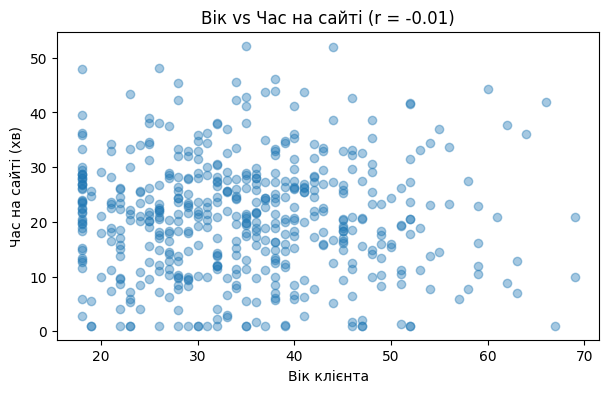

❌ Статистично значущої кореляції НЕ виявлено


In [45]:
# Завдання 20:
# ===========================================
# Задача D: кореляція age та session_min
# ===========================================

r, p_value = stats.pearsonr(df["age"], df["session_min"])

print(f"Коефіцієнт кореляції r: {r:.3f}")
print(f"p-значення: {p_value:.4f}")

plt.figure(figsize=(7, 4))
plt.scatter(df["age"], df["session_min"], alpha=0.4)
plt.xlabel("Вік клієнта")
plt.ylabel("Час на сайті (хв)")
plt.title(f"Вік vs Час на сайті (r = {r:.2f})")
plt.show()

if p_value < 0.05:
    print("✅ Кореляція статистично значуща")
else:
    print("❌ Статистично значущої кореляції НЕ виявлено")


#### 💬 Інтерпретація 22

Опишіть звʼязок (напрямок, сила, значущість).

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Кореляція між віком і часом на сайті: `r ≈ -0.012`, p-значення ≈ **0.7898**. Знак мінусовий, але значення майже нульове, тому зв'язок практично відсутній. Оскільки `p ≥ 0.05`, статистично значущого лінійного зв'язку між віком клієнта та часом на сайті **не виявлено**.


---
# 🎉 Вітаємо із завершенням!

Ви пройшли повний цикл роботи аналітика зі статистичними тестами:

- ✅ Одновибірковий, двовибірковий та парний t-тести
- ✅ ANOVA для 3+ груп
- ✅ Хі-квадрат для категоріальних даних
- ✅ Кореляція для числових змінних
- ✅ Повноцінний A/B-тест
- ✅ Самостійний вибір тесту під задачу

## Головне, що варто винести

1. **Вибір тесту** важливіший за код. Завжди питайте: який тип даних? скільки груп? незалежні чи парні?
2. **p-значення** саме по собі — це лише число. Цінність створює ваша **інтерпретація**.
3. **Контекст вирішує:** памʼятайте про розмір ефекту, практичну значущість і те, що кореляція ≠ причинність.

## Питання для самоперевірки
- Чи можете ви пояснити різницю між парним і двовибірковим t-тестом?
- Чому не можна замінити одну ANOVA трьома t-тестами?
- Що означає «не відхилили H₀» — чи це те саме, що «довели, що ефекту немає»?

Якщо на всі три питання ви відповідаєте впевнено — ви добре засвоїли тему. Так тримати! 📊


---
## ✅ Загальний підсумок роботи

У цьому практикумі були використані основні статистичні тести:

- **Одновибірковий t-тест**: середній час сесії не відрізняється від 20 хв, а середні витрати не відрізняються від 850 грн, але значущо нижчі за 900 грн.
- **Двовибірковий t-тест**: витрати Mobile/Desktop та час сесії чоловіків/жінок статистично значущо не відрізняються.
- **Парний t-тест**: після редизайну задоволеність клієнтів значущо зросла.
- **ANOVA**: витрати значущо відрізняються між каналами, найвищі середні витрати у каналі «Реклама». За країнами для часу сесії та за каналами для віку значущої різниці не виявлено.
- **Хі-квадрат**: канал не має значущого зв'язку з покупкою, стать не має значущого зв'язку з пристроєм, країна не має значущого зв'язку з пристроєм.
- **Кореляція Пірсона**: між часом на сайті та витратами є сильний прямий значущий зв'язок (`r ≈ 0.732`). Вік майже не пов'язаний ні з витратами, ні з часом на сайті.
- **A/B-тест**: версія B має конверсію **11.90%**, версія A — **10.10%**. Різниця **+1.80 відсоткового пункту** статистично значуща (`p ≈ 0.0112`), тому версію B можна рекомендувати до впровадження.
